In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import scipy.stats as sts
from scipy.stats import norm
import statsmodels.api as sm
cwd = os.getcwd()
print(cwd)

# glob allows us to get all the files in a directory with a specific pattern. It returns a list of file paths that match the pattern.

c:\Users\georg.LAPTOP-1GUGHKRH\OneDrive - University College London\Shared Python code\Python Code\Market Microstructure\Exercises\Lab 2


In [2]:
stocks = ['TSLA','FB','GOOG','JNJ','MSFT','TSLA']
all_files = []
for stock in stocks:
    all_files.extend(glob.glob(f"./Stocks/{stock}/cleaned_data/*.*"))

all_files


['./Stocks/TSLA/cleaned_data\\TSLA_2019-01-03_34200000_57600000_orderbook_10.csv',
 './Stocks/FB/cleaned_data\\FB_2019-01-03_34200000_57600000_orderbook_10.csv',
 './Stocks/GOOG/cleaned_data\\GOOG_2019-01-03_34200000_57600000_orderbook_10.csv',
 './Stocks/JNJ/cleaned_data\\JNJ_2019-01-03_34200000_57600000_orderbook_10.csv',
 './Stocks/MSFT/cleaned_data\\MSFT_2019-01-03_34200000_57600000_orderbook_10.csv',
 './Stocks/TSLA/cleaned_data\\TSLA_2019-01-03_34200000_57600000_orderbook_10.csv']

In [3]:
df = pd.read_csv(all_files[0])
print(df.shape)
df.head(3)

(546078, 46)


,DateTime,Event_Type,Order_ID,Size,Price,Direction,Ask_Price_Level_1,Ask_Volume_Level_1,Bid_Price_Level_1,Bid_Volume_Level_1,...,Bid_Price_Level_8,Bid_Volume_Level_8,Ask_Price_Level_9,Ask_Volume_Level_9,Bid_Price_Level_9,Bid_Volume_Level_9,Ask_Price_Level_10,Ask_Volume_Level_10,Bid_Price_Level_10,Bid_Volume_Level_10
0,2019-01-03 09:30:00:708346,1,13167276.0,50,3065300.0,1,307.2,1000,307.0,244,...,306.06,12,308.12,200,306.0,135,308.24,100,305.6,1
1,2019-01-03 09:30:00:716851,4,NaN,25,3070000.0,1,307.2,1000,307.0,219,...,306.06,12,308.12,200,306.0,135,308.24,100,305.6,1
2,2019-01-03 09:30:00:716886,4,NaN,128,3070000.0,1,307.2,1000,307.0,91,...,306.06,12,308.12,200,306.0,135,308.24,100,305.6,1


In [4]:
df.describe()


,Event_Type,Order_ID,Size,Price,Direction,Ask_Price_Level_1,Ask_Volume_Level_1,Bid_Price_Level_1,Bid_Volume_Level_1,Ask_Price_Level_2,...,Bid_Price_Level_8,Bid_Volume_Level_8,Ask_Price_Level_9,Ask_Volume_Level_9,Bid_Price_Level_9,Bid_Volume_Level_9,Ask_Price_Level_10,Ask_Volume_Level_10,Bid_Price_Level_10,Bid_Volume_Level_10
count,546078.000000,5.261730e+05,546078.000000,5.460780e+05,546078.000000,546078.000000,546078.000000,546078.000000,546078.000000,546078.000000,...,546078.000000,546078.000000,546078.000000,546078.000000,546078.000000,546078.000000,546078.000000,546078.000000,546078.000000,546078.000000
mean,2.051300,2.287246e+08,64.927181,3.020551e+06,-0.037478,302.144896,177.739134,301.963085,455.626780,302.192278,...,301.740979,223.553252,302.415765,128.485597,301.712890,232.097601,302.446233,131.127659,301.683939,218.883605
std,1.072458,1.312834e+08,83.461388,1.860334e+04,0.999298,1.864649,372.615142,1.834622,2341.115778,1.872715,...,1.794868,1526.508982,1.906455,321.058413,1.791828,1516.307501,1.911329,334.085805,1.788790,1231.839908
min,1.000000,4.011572e+06,1.000000,2.972300e+06,-1.000000,297.390000,1.000000,297.380000,1.000000,297.470000,...,297.230000,1.000000,297.750000,1.000000,297.200000,1.000000,297.770000,1.000000,297.180000,1.000000
25%,1.000000,1.089813e+08,50.000000,3.005600e+06,-1.000000,300.610000,50.000000,300.480000,70.000000,300.660000,...,300.300000,50.000000,300.860000,50.000000,300.270000,50.000000,300.890000,50.000000,300.250000,50.000000
50%,3.000000,2.239623e+08,50.000000,3.018800e+06,-1.000000,301.940000,100.000000,301.790000,100.000000,301.980000,...,301.550000,100.000000,302.180000,80.000000,301.520000,100.000000,302.210000,100.000000,301.500000,100.000000
75%,3.000000,3.429523e+08,70.000000,3.033900e+06,1.000000,303.500000,200.000000,303.260000,200.000000,303.540000,...,303.000000,123.000000,303.760000,100.000000,302.990000,125.000000,303.790000,100.000000,302.940000,120.000000
max,5.000000,4.684662e+08,6824.000000,3.101200e+06,1.000000,309.500000,8093.000000,309.050000,42259.000000,309.560000,...,307.070000,43420.000000,310.120000,8360.000000,307.000000,43420.000000,310.270000,8360.000000,306.900000,43420.000000


In [5]:
df.dtypes

DateTime                object
Event_Type               int64
Order_ID               float64
Size                     int64
Price                  float64
Direction                int64
Ask_Price_Level_1      float64
Ask_Volume_Level_1       int64
Bid_Price_Level_1      float64
Bid_Volume_Level_1       int64
Ask_Price_Level_2      float64
Ask_Volume_Level_2       int64
Bid_Price_Level_2      float64
Bid_Volume_Level_2       int64
Ask_Price_Level_3      float64
Ask_Volume_Level_3       int64
Bid_Price_Level_3      float64
Bid_Volume_Level_3       int64
Ask_Price_Level_4      float64
Ask_Volume_Level_4       int64
Bid_Price_Level_4      float64
Bid_Volume_Level_4       int64
Ask_Price_Level_5      float64
Ask_Volume_Level_5       int64
Bid_Price_Level_5      float64
Bid_Volume_Level_5       int64
Ask_Price_Level_6      float64
Ask_Volume_Level_6       int64
Bid_Price_Level_6      float64
Bid_Volume_Level_6       int64
Ask_Price_Level_7      float64
Ask_Volume_Level_7       int64
Bid_Pric

In many financial datasets, timestamps are initialy stored as string objects. In order to perform time-based operations (e.g, filtering, resampling and plotting) it is essential to convert these strings into datetime objects. 
```python
df.DateTime = pd.to_datetime(df.DateTime, format = '%Y-%m-%d %H:%M:%S:%f')
``` 
This command tells pandas to conver the DateTime column into proper timestamp format. Parse the data and time using the specified format %Y = 4 digit year m 2 digit month d 2 digit day H hour 24 hour format M minute S second f microsecond.

After conversion the column becomes a datetime64[ns] type enabling time-aware operations suhc as:
- Time-based filtering df[df.DateTime > '']
- Resampling df.set_index('DateTime').resample("1min").mean()
- Time series plotting with matplotlib
- 


In [6]:
df['DateTime'] = pd.to_datetime(df['DateTime'], format='%Y-%m-%d %H:%M:%S:%f')

In [7]:
df.dtypes

DateTime               datetime64[ns]
Event_Type                      int64
Order_ID                      float64
Size                            int64
Price                         float64
Direction                       int64
Ask_Price_Level_1             float64
Ask_Volume_Level_1              int64
Bid_Price_Level_1             float64
Bid_Volume_Level_1              int64
Ask_Price_Level_2             float64
Ask_Volume_Level_2              int64
Bid_Price_Level_2             float64
Bid_Volume_Level_2              int64
Ask_Price_Level_3             float64
Ask_Volume_Level_3              int64
Bid_Price_Level_3             float64
Bid_Volume_Level_3              int64
Ask_Price_Level_4             float64
Ask_Volume_Level_4              int64
Bid_Price_Level_4             float64
Bid_Volume_Level_4              int64
Ask_Price_Level_5             float64
Ask_Volume_Level_5              int64
Bid_Price_Level_5             float64
Bid_Volume_Level_5              int64
Ask_Price_Le

# Question 1: Mid Price Computation

Compute the mid-price and add it into an extra dataframe column.

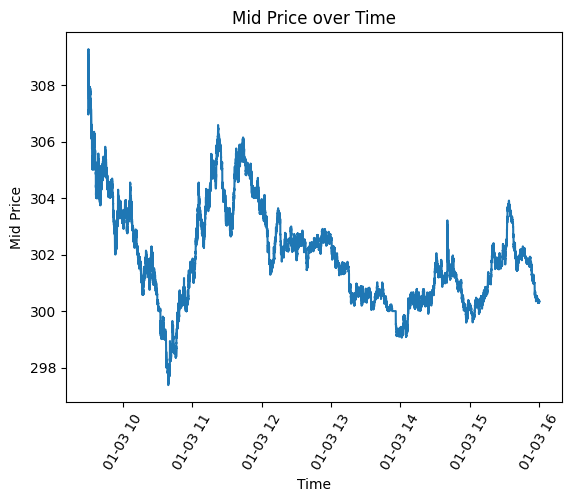

In [8]:
df['Mid-Price'] = (df['Bid_Price_Level_1'] + df['Ask_Price_Level_1']) /2

plt.plot(df['DateTime'], df['Mid-Price'])
plt.xlabel('Time')
plt.ylabel('Mid Price')
plt.title('Mid Price over Time')
plt.xticks(rotation=60)
plt.show()

Then we extend this by resampling the mid price at 1-minute intervals using the last observed value in each 1-minute bin 

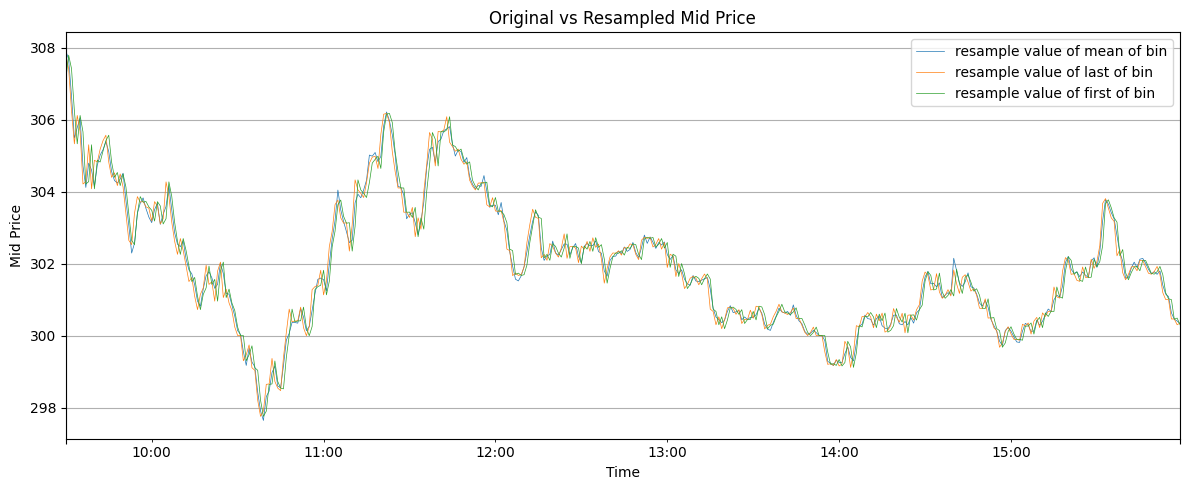

In [9]:
df.set_index('DateTime', inplace = True, drop = False)

resampled_mid_mean = df['Mid-Price'].resample("1Min").mean()
resampled_mid_last = df['Mid-Price'].resample("1Min").last()
resampled_mid_first = df['Mid-Price'].resample("1Min").first()


plt.figure(figsize = (12,5))
resampled_mid_mean.plot(label = 'resample value of mean of bin', linewidth=0.5)
resampled_mid_last.plot(label = 'resample value of last of bin', linewidth =0.5)  
resampled_mid_first.plot(label = 'resample value of first of bin', linewidth =0.5)  
plt.xlabel('Time')
plt.ylabel('Mid Price')
plt.title('Original vs Resampled Mid Price')
plt.legend()
plt.xticks(rotation=60)
plt.tight_layout()
plt.grid(True)
plt.show()


# Question 2) Stock Properties

COmpute Average Spread, tick size/ minimum price increment, average mid price over trading day, empirical tick size to determine the stock class

In [10]:
average_spread = np.mean(df['Ask_Price_Level_1'] - df['Bid_Price_Level_1'])
print(f"Average spread for the stock {stock} : {round(average_spread, 4)}")

Average spread for the stock TSLA : 0.1818


In [11]:
prices_volumes = df.iloc[:, 6:-1]
prices_ask_side = prices_volumes.iloc[:, 0::4]
prices_bid_side = prices_volumes.iloc[:, 2::4]

flatten_ask_diff = np.array(prices_ask_side.diff(axis = 1).iloc[:, 1:]).flatten()
flatten_bid_diff = np.array(prices_bid_side.diff(axis = 1).iloc[:, 1:]).flatten()

flatten_bid_ask = np.concatenate((flatten_ask_diff, flatten_bid_diff))

tick_size = np.min(np.abs(flatten_bid_ask))
print(tick_size)

0.009999999999990905


In [12]:
# Average mid-price over trading day

average_mid = np.mean(df['Mid-Price'])
print(f"Average mid for stock {stock}: {round(average_mid, 2)}")

Average mid for stock TSLA: 302.05


In [13]:
relative_tick_size = tick_size / average_mid
print(f"{relative_tick_size:.6f}")
print(f" as the relative tick size {relative_tick_size:.6f} is less than 0.00004 this means the stock falls into the criteria of a small tick stock")

0.000033
 as the relative tick size 0.000033 is less than 0.00004 this means the stock falls into the criteria of a small tick stock


### Question 3) Return Computation via Binned Mid-Prices

First aggregate the mid-price data into fixed time intervals and compute the open High Low and Close OHLC prices within each bin. 

Then use the close price from each bin to comput log returns: $$r_t = log(C_t) - log(C_{t-\Delta t})$$

try multiple bin sizes for delta t such as 1 s 10s and 1 minute. Plot the resulting return series for each frequency and discuss how return behavour changes across scales.

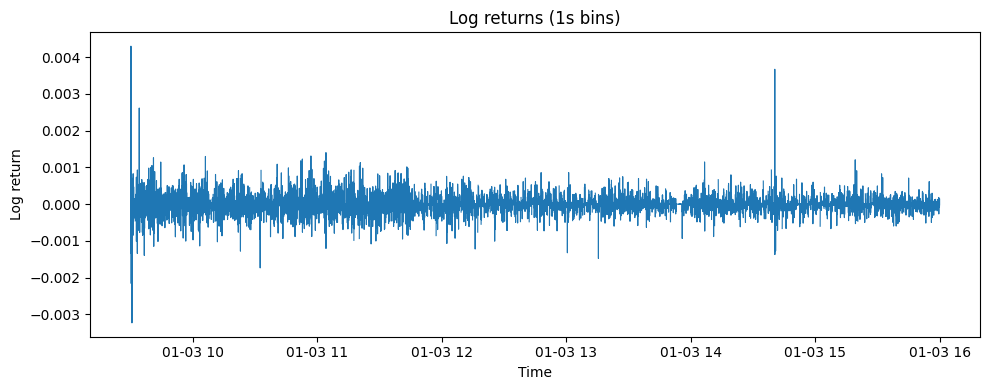

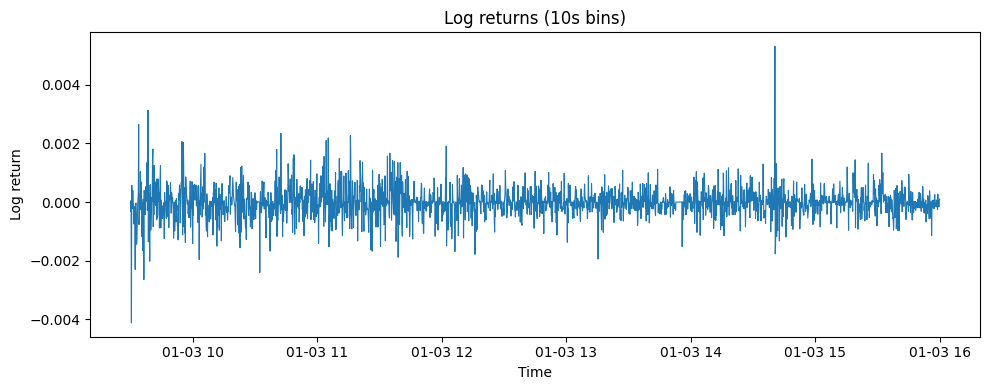

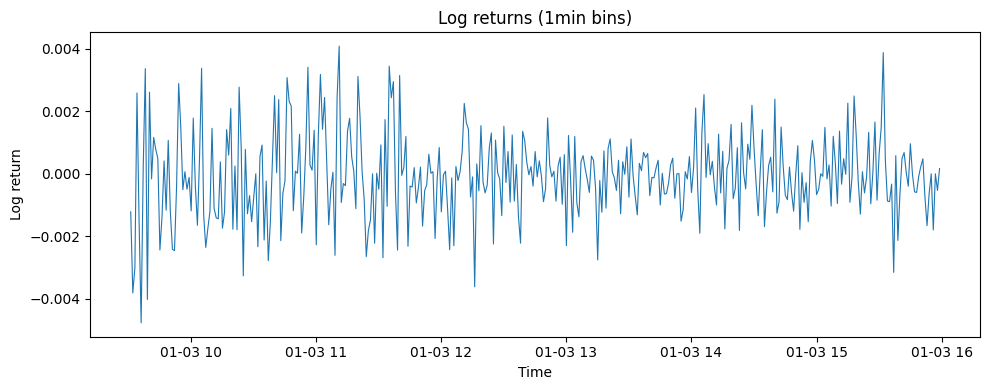

In [14]:
df = df.set_index("DateTime", drop = False)
for bin_size in ["1s", "10s", "1min"]:
    ohlc = df["Mid-Price"].resample(bin_size).ohlc()
    ohlc["log_return"] = (np.log(ohlc["close"]) - np.log(ohlc["close"].shift(1))).dropna()

    plt.figure(figsize = (10,4))
    plt.plot(ohlc.index, ohlc["log_return"], lw = 0.8)
    plt.title(f"Log returns ({bin_size} bins)")
    plt.xlabel("Time")
    plt.ylabel("Log return")
    plt.tight_layout()
    plt.show()

As the bin size increases there is less noise


# Question 4) Return Distribution 
Plot histograms of log returns for differentbins. Compare them to a Gaussian distribution

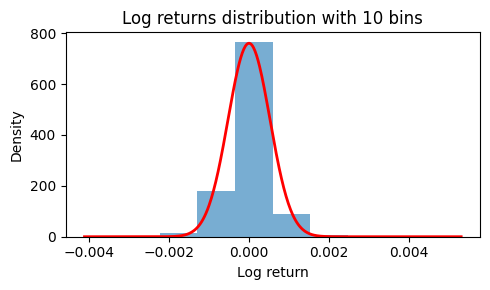

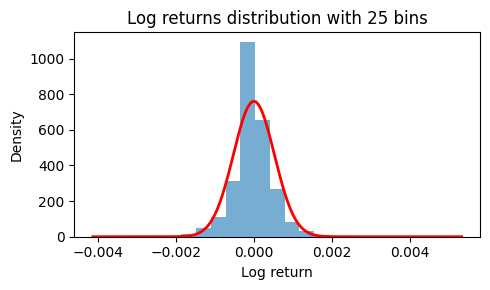

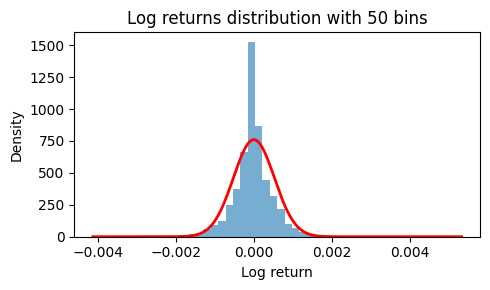

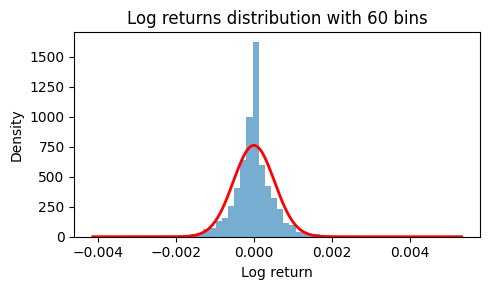

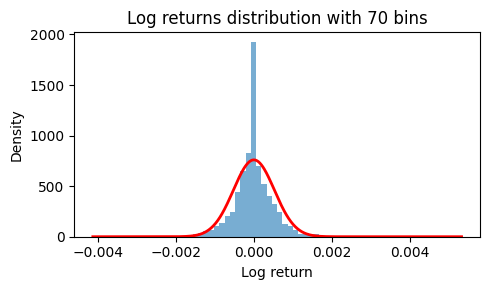

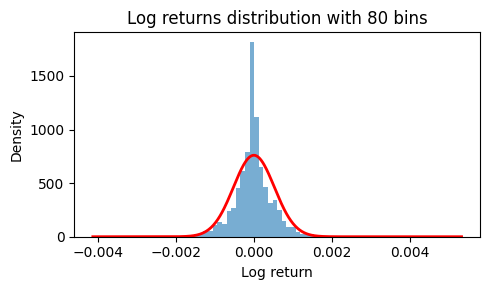

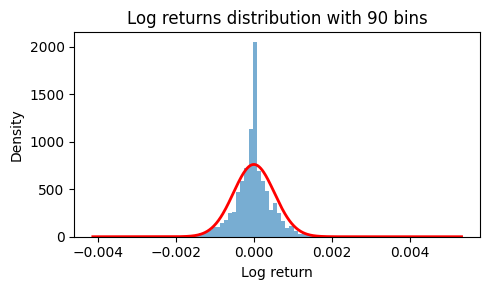

In [15]:
close_returns_10s = df['Mid-Price'].resample('10s').last()

log_close_returns = (np.log(close_returns_10s) - np.log(close_returns_10s).shift()).dropna()
sigma = log_close_returns.std()
x = np.linspace(log_close_returns.min(), log_close_returns.max(), 500)
pdf = norm.pdf(x, loc=0, scale=sigma)

for bins in [10, 25, 50, 60, 70, 80, 90]:
    plt.figure(figsize=(5,3))
    plt.hist(log_close_returns, bins=bins, density=True, alpha=0.6)
    plt.plot(x, pdf, color="red", linewidth=2)
    plt.xlabel('Log return')
    plt.ylabel('Density')
    plt.title(f"Log returns distribution with {bins} bins")
    plt.tight_layout()
    plt.show()


The logreturns are much narrower than the gaussian distribution, this would mean imply that log returns are leptokurtic/ heavvy tailed as we have empirically observed and have treated that in the presence of heteroskedastic/ stochastic volatility there is always non negative excess kurtosis.

### Question 5) Empirical Kurtosis

Compute the empirical excess kurtosis of the the return distribution, the formula for the excess kurtosis is: $$ \kappa(r) = \frac {E[(r-\mu)^4]}{\sigma^4} - 3$$

how do we compute this empirically, does this suggest fat tails, compare this across time bins.

the empirical kurtosis is :
$$
\kappa
=
\frac{\left\langle (y_t-\bar y)^4 \right\rangle_t}{\sigma^4}
- 3 .
$$

This is empirical as it uses sample moments not expectations under a probabiliyt measure. The brackes are sample time averages not expectations

In [20]:
def compute_empirical_kurtosis(arr):
    mean_ = np.mean(arr)
    muprime2 = np.mean((arr - mean_)**2)
    muprime4 = np.mean((arr-mean_)**4)
    kurtosis = (muprime4 / (muprime2**2)) - 3
    return kurtosis

In [24]:
print(f"Empirical excess kurtosis of {stock} stock's returns is equal to {round(compute_empirical_kurtosis(log_close_returns), 2)}.")

Empirical kurtosis of TSLA stock's returns is equal to 8.77.


The returns have positive excesss kurtosis hence the distribution of log returns is leptokurtic and have heavier tails than the gaussian distribution, there is higher probability density in the tails than the gaussian this means for an interval of large returns either positive or negative there is a higher probability that we get returns in this interval than in the gaussian distribution as probability is defined only over an interval.

Studying the empirical distribution function / empirical cumulative distribution function by the formula:

$$
\widehat F_Y(y)
=
\frac{\left|\{\, y_n \mid y_n \le y \,\}\right|}{N}
=
\frac{1}{N}\sum_{n=1}^N \mathbf{1}_{\{y_n \le y\}}
$$


In [ ]:
import scipy as sp
from statsmodels import norm

In [ ]:
def ccdf(data):
    x = np.array(sorted(data))
    y = np.linspace(1, len(data) + 1, len(data))

    y = 1 - (y/ (len(data) + 1))

    return(x,y)

# that is we order all the points and find what percentage of data the point is greater than by dividing the y position by the length of the data + 1 to accoutn for end and 1 - this value 


def gaussian_ccdf(data):
    x = np.sort(data)
    N = len(x)
    mean = np.mean(x)
    std = np.sqrt(np.mean((x - mean)**2))  # population std

    y = 1 - norm.cdf(x, loc=mean, scale=std)
    return x, y





<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

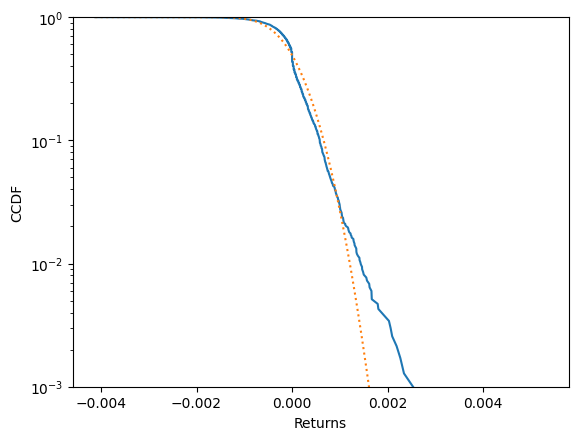

In [36]:
ccdf_rets_x, ccdf_rets_y = ccdf(log_close_returns)
ccdf_gaussian_x, ccdf_gaussian_y = gaussian_ccdf(log_close_returns)


plt.semilogy(ccdf_rets_x, ccdf_rets_y, label = 'Empirical CCDF')
plt.semilogy(ccdf_gaussian_x, ccdf_gaussian_y, label = 'Gaussian CCDF', ls = 'dotted')
plt.xlabel('Returns')
plt.ylabel('CCDF')
plt.ylim(10e-4, 1)
plt.legend


This gives us the probability that our data is larger than x value. But this trick when we order the data, we don't have to fix the bin and count how many events are in the bin to get the probability via frequency we can simply order the data and use the data as the mesha dn then use the rank as the proxy for the ccdf we see that there is a higher probabilty of values greater than 


# Question 6) Return Autocorrelation

Compute the autocorrelation function (ACF) of returns:
- plot ACF for raw returns and absolute returns 


The autocovariance funciton of a set of observations of the quantity Y is 

$$C(l) = C_Y(l) = <y_{t+l}y_t>_t - \space \bar y_t ^2 $$

The empirical autocovariance fucntion 

$$ C_{emp}(l) = \frac{1}{N-l} \sum ^{n-1} _{k=1} \tilde X_k \tilde X_{k+l}$$

the empirical autocorrelation is this divided by the sample variance

in the case wehre the mean is zero


Text(0, 0.5, 'Autocorrelation')

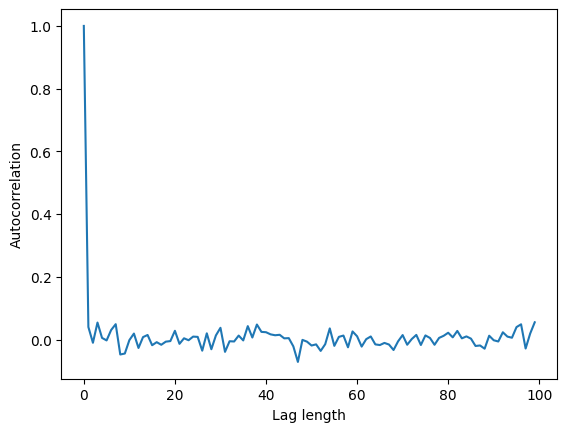

In [44]:
lags = range(100)

acorr = len(lags) * [0]

mean = sum(log_close_returns) / len(log_close_returns) # sample mean/ time average

var = sum([(x - mean)**2 for x in log_close_returns]) / len(log_close_returns) # sample variance 

ndata = [x - mean for x in log_close_returns] # centered data for E[x- mu] = X tild

for l in lags:
    c = 1

    if (l > 0):
        tmp = [ndata[l:][i] * ndata[:-l][i] for i in range(len(ndata)-l)]

        # ndata[l:] is the shifted series starting from l 
        # ndata[:-l] is the unshifted series
        # the list comprehension multiplies them element wise by doing i

        c = sum(tmp) / (len(ndata)) / var  # len = N-L/N 

        # average and normalise by autocorrelation with zero lag which is variance  your autocorrelation estimate

    acorr[l] = c


plt.plot(acorr)
plt.xlabel('Lag length')
plt.ylabel('Autocorrelation')



Text(0, 0.5, 'Autocorrelation')

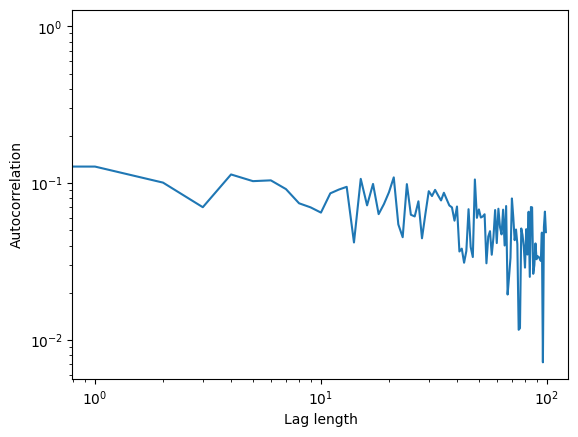

In [43]:
lags = range(100)

acorr = len(lags) * [0]

absolute_returns = np.abs(log_close_returns)

mean = sum(absolute_returns) / len(absolute_returns) # sample mean/ time average

var = sum([(x - mean)**2 for x in absolute_returns]) / len(absolute_returns) # sample variance 

ndata = [x - mean for x in absolute_returns] # centered data for E[x- mu] = X tild

for l in lags:
    c = 1

    if (l > 0):
        tmp = [ndata[l:][i] * ndata[:-l][i] for i in range(len(ndata)-l)]

        # ndata[l:] is the shifted series starting from l 
        # ndata[:-l] is the unshifted series
        # the list comprehension multiplies them element wise by doing i

        c = sum(tmp) / (len(ndata)) / var  # len = N-L/N 

        # average and normalise by autocorrelation with zero lag which is variance  your autocorrelation estimate

    acorr[l] = c


plt.plot(acorr)
plt.xscale('log') # sets axis to be log scaled
plt.yscale('log')
plt.xlabel('Lag length')
plt.ylabel('Autocorrelation')



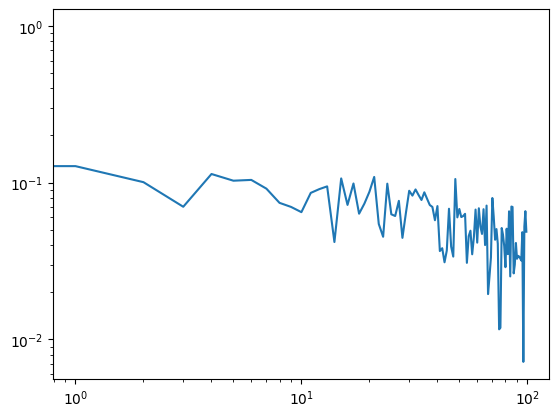

In [47]:
# Compute the same quantities using a library

acorr = sm.tsa.acf(absolute_log_returns, nlags = len(lags) - 1)
plt.plot(acorr)
plt.xscale('log')
plt.yscale('log')

Critically you could say only on a log scale do these returns appear non zero or show persistance, on a linear scale we see autocorrelation is close to zero

For raw (log) returns, the empirical autocorrelation decays immediately to values approximately zero when plotted on a linear scale, consistent with lack of correlation of returns. In contrast the autocorrelation of aboslute log-returns remains positive over many lags and exhibits slow decay on log log axes, indicating volatility clustering and long range dependence in return magnitudes.

Raw returns show no significant linear autocorrelation, whereas absolute returns display persistent, slowly decaying autocorrelation, evidencing volatility clustering. 


Better put according to the lecture notes:

Linear autocorrelations of returns are small or absent (except on a very small intradya time scale)

If price changes exhibit significant correlation this correlation may be used to conveive a simple strategy with positive expected earnings such strategies are called statistical arbitarage will therefore tend to reduce the correlations except for very small short time scales, which represent the time markets take to react. 


# Q7) Volatility Estimation

Estimate daily volatility using standard deviation of returns over the trading day.

First we compute the variogram which is the average of mean squared distances between observations

In [65]:
vdata = np.array(log_close_returns)

var = sum([(x - mean)**2 for x in vdata]) / len(vdata)

vvalues = len(lags) * [0]

for l in lags:
    c = 1

    if (l>0):
        tmp = []
        for i in range(len(vdata) - l): # all pairs (i, i+l)
            tmp.append((vdata[l:][i] - vdata[:-l][i])**2)

        c = sum(tmp) / (2* len(vdata)) / var

    vvalues[l] = c

Text(0.5, 1.0, 'Variogram')

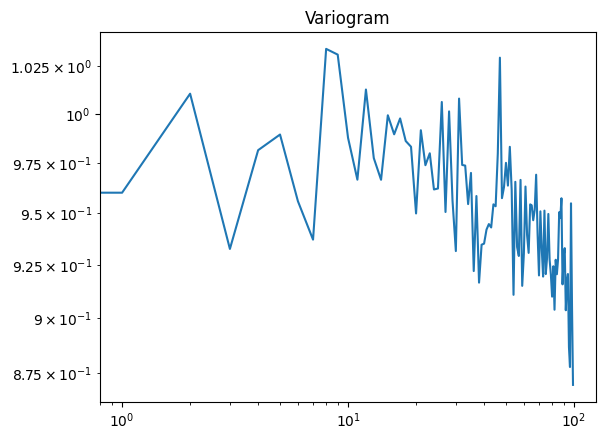

In [66]:
plt.plot(lags,vvalues)
plt.xscale('log')
plt.yscale('log')
plt.title('Variogram')

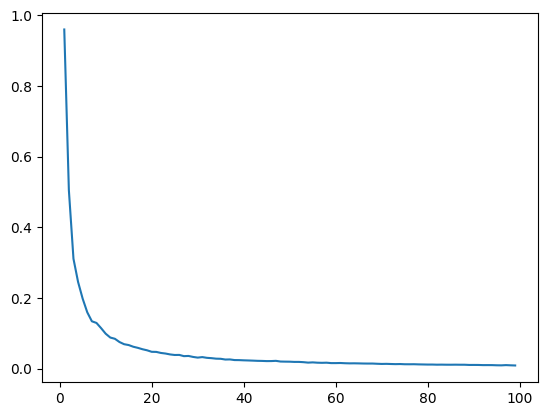

In [67]:
# signature plot

signature_lags = lags[1:]
signature = np.array(vvalues)[1:]/ signature_lags

plt.plot(signature_lags, signature)

A high frequency proxy of the volatility is the absolute return |rn|

In [77]:
mean_return = log_close_returns.mean()

volatility = np.sqrt(np.mean((log_close_returns - mean_return)**2))


print(f" Daily volatility estimate = std of intraday log-returns over the day: {volatility:.6f}")

absolute_returns = np.abs(log_close_returns)
print(f"Estimate using the average of absolute returns : {np.mean(absolute_returns):.6f}")

 Daily volatility estimate = std of intraday log-returns over the day: 0.000525
Estimate using the average of absolute returns : 0.000344


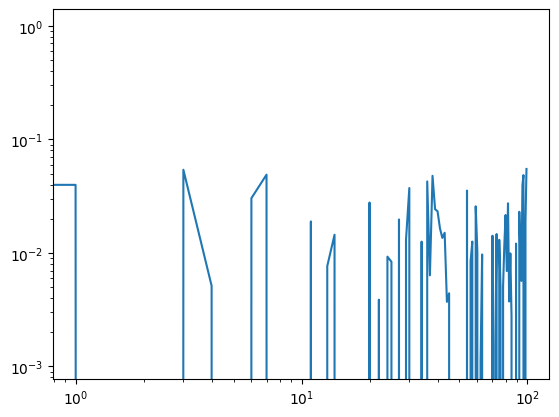

In [89]:

acorr = sm.tsa.acf(log_close_returns, nlags = len(lags) - 1)
plt.loglog(acorr)


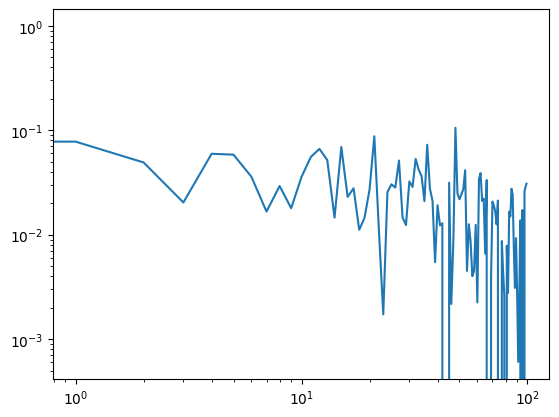

In [88]:
squared_returns = np.square(log_close_returns)


acorr = sm.tsa.acf(squared_returns, nlags = len(lags) - 1)
plt.loglog(acorr)

Note the autocorrelation is numerically small so when plotted on a linear linear plot the  y axis is dominated by short lags and we see slow decay over long horizons is visually flattened

the log-log plot reveals clustering as we see a straight line can be fitted meaning correlations decay algebraically rather than exponentially. We have persistance autocorrelations. We have positve autocorrelation at all lags this rules out constant volatility. As l increase the autocorrelation decays by roughly one order of magnitude despte going from lag 1 to 100, this means that we have power law decay/ slower than exponential decay associated with short memory processes. This indicates volatility clustering and long memory in absolute returns, consistent with returns being  driven by a stochastic volatility process with long memory rather than constant volatility.



# Question 9 Order Flow correlations

Consider the order flow signs ('Direction') for market orders and compute the auto-correlation function, which property do you observe.

In [106]:
def compute_sign_acf(signs, max_lag):
    n = len(signs)
    mean = sum(signs) / n
    var = sum((s-mean)**2 for s in signs) / n

    acf = []
    for lag in range(max_lag + 1):
        cov = sum(  (signs[t] - mean) * (signs[t+lag] - mean) for t in range(n-lag)) / (n-lag)
        acf.append(cov/ var)
    return acf

In [107]:
signs = df[df['Event_Type'].isin([4,5])]['Direction'].dropna().astype(int).tolist()
acf_vals = compute_sign_acf(signs, max_lag=50)
print(acf_vals)


[1.0, 0.4458330599523472, 0.30046960452175664, 0.22032008575157574, 0.16672885286422692, 0.12206522836305611, 0.09813240022708464, 0.08083975306114397, 0.06686682786357244, 0.06005575397987657, 0.049623626453550465, 0.04731740828529191, 0.04759153102335136, 0.04639241051082832, 0.03750798052036999, 0.03194528629858898, 0.027566776614224183, 0.029978134953041746, 0.01983899340419596, 0.018339405525984342, 0.016097813202763506, 0.02323932883598675, 0.02528507119419323, 0.02031706408053398, 0.017188684694767788, 0.02270317179886865, 0.018466441804384177, 0.019548701437546702, 0.025285793044237823, 0.02880681562214541, 0.02412618848471665, 0.023734345561732935, 0.016469822293369938, 0.01112273996599877, 0.01442221535654184, 0.011070075868012744, -0.001518372693073754, 0.0013374568787482344, 0.0015323933625330571, 0.0059410974921281145, 0.00754424798983829, 0.007816768653748949, 0.007568451178808863, 0.01086924270014076, 0.01394853456702984, 0.015996178298850108, 0.013529678837930381, 0.012

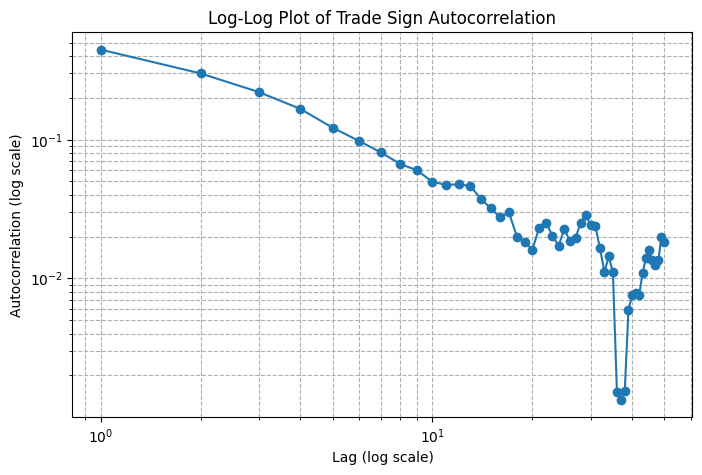

In [108]:


lags = np.arange(1, len(acf_vals)) # skip lag 0
acf_values = np.array(acf_vals[1:]) # skip lag 0 value

plt.figure(figsize=(8, 5))
plt.loglog(lags, np.abs(acf_values), marker='o', linestyle='-')
plt.xlabel('Lag (log scale)')
plt.ylabel('Autocorrelation (log scale)')
plt.title('Log-Log Plot of Trade Sign Autocorrelation')
plt.grid(True, which='both', ls='--')
plt.show()

The log log plot of trade sign autocorrelations exhibits an approximately linear decay over several lags, indicating power-law decay and long-range dependence in order flow; the noisy tail reflects finite-sample effects rather than a breakdown of persistence.

In [109]:
df

,DateTime,Event_Type,Order_ID,Size,Price,Direction,Ask_Price_Level_1,Ask_Volume_Level_1,Bid_Price_Level_1,Bid_Volume_Level_1,...,Bid_Volume_Level_8,Ask_Price_Level_9,Ask_Volume_Level_9,Bid_Price_Level_9,Bid_Volume_Level_9,Ask_Price_Level_10,Ask_Volume_Level_10,Bid_Price_Level_10,Bid_Volume_Level_10,Mid-Price
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-01-03 09:30:00.708346,2019-01-03 09:30:00.708346,1,13167276.0,50,3065300.0,1,307.20,1000,307.00,244,...,12,308.12,200,306.00,135,308.24,100,305.60,1,307.100
2019-01-03 09:30:00.716851,2019-01-03 09:30:00.716851,4,NaN,25,3070000.0,1,307.20,1000,307.00,219,...,12,308.12,200,306.00,135,308.24,100,305.60,1,307.100
2019-01-03 09:30:00.716886,2019-01-03 09:30:00.716886,4,NaN,128,3070000.0,1,307.20,1000,307.00,91,...,12,308.12,200,306.00,135,308.24,100,305.60,1,307.100
2019-01-03 09:30:00.716934,2019-01-03 09:30:00.716934,5,NaN,230,3070000.0,-1,307.20,1000,306.99,10,...,135,308.12,200,305.60,1,308.24,100,305.50,11,307.095
2019-01-03 09:30:00.716974,2019-01-03 09:30:00.716974,3,13167276.0,50,3065300.0,1,307.20,1000,306.99,10,...,1,308.12,200,305.50,11,308.24,100,305.41,8,307.095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-03 15:59:59.910750,2019-01-03 15:59:59.910750,3,468465192.0,100,3003400.0,1,300.36,1100,300.35,865,...,100,300.48,150,300.26,1774,300.50,2764,300.25,1689,300.355
2019-01-03 15:59:59.910750,2019-01-03 15:59:59.910750,1,468465512.0,100,3003500.0,1,300.36,1100,300.35,965,...,100,300.48,150,300.26,1774,300.50,2764,300.25,1689,300.355
2019-01-03 15:59:59.914280,2019-01-03 15:59:59.914280,3,468465512.0,100,3003500.0,1,300.36,1100,300.35,865,...,100,300.48,150,300.26,1774,300.50,2764,300.25,1689,300.355


# Lag 1 response function

Calculation of the lag-1 response for market orders and compare it to the spread flucutaitons and price fluctuations.

In [ ]:
def calculate_lag1_response_slow(data):

    # Note lag 1 response

    '''
    R(1) = < epsilon_t * (m_{t+1} - m_{t})>


    '''

    event = data['Event_Type'].to_numpy()
    eps = data['Direction'].to_numpy()
    ask = data['Ask_Price_Level_1'].to_numpy()
    bid = data['Bid_Price_Level_1'].to_numpy()

    mid = data['Mid-Price'].to_numpy()


    dmid = mid[2:] - mid[:-2] # this alligns with t = 1, ... N-2

    eps_t = eps[1:-1]
    is_mo = (event[1:-1] == 4) | (event[1:-1] == 5)

    spread_before = (ask[:-2] - bid[:-2]) 

    dmid_mo = dmid[is_mo]


    eps_mo = eps_t[is_mo]
    spread_mo = spread_before[is_mo]

    Number_of_market_orders = dmid_mo.size
    if Number_of_market_orders == 0:#
        return 0.0, 0.0, 0.0 
    
    r_signed = -eps_mo * dmid_mo # term inside lag reponse function

    avg_spread = spread_mo.mean()
    
    R1 = r_signed.mean()

    V1 = (dmid_mo **2).mean()

    return float(avg_spread), float(R1), float(V1)

    
# not sure if this is entirely corrrect but lag 1 response function is correct the main thing

# to note is for doing the lag difference to allign the mid prices

# df['Mid-Price'][l:] - df['Mid_price'][:-l] # that is all midprices starting from l and all midprices up to l


In [ ]:
print(calculate_lag1_response_slow(df))

(0.1160597839738753, 0.02368374780205963, 0.0024655023863350764)


### Order Flow Imbalance

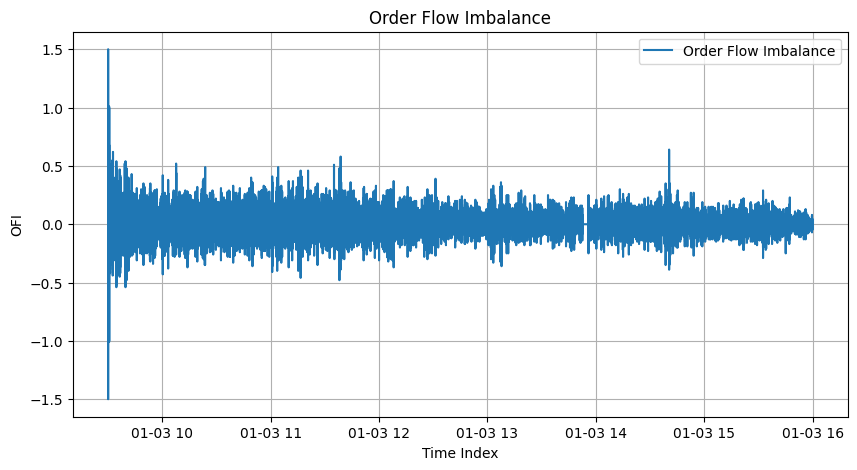

In [116]:
def compute_ofi(df):

    ''' Compute order Flow OFI using Cont-Stoikov 2011 definition 
    '''

    event_level_bid_side_order_flow_change_in_bid_queues = df['Bid_Price_Level_1'].diff()
    event_level_ask_side_order_flow_change_in_ask_queues = df['Ask_Price_Level_1'].diff()

    # OFI = bidsideorderflowimbalance - asksideorderflowimbalance

    ofi = event_level_bid_side_order_flow_change_in_bid_queues - event_level_ask_side_order_flow_change_in_ask_queues

    return ofi

df['OFI'] = compute_ofi(df)

import matplotlib.pyplot as plt

plt.figure(figsize = (10,5))
plt.plot(df['OFI'], label='Order Flow Imbalance')
plt.title('Order Flow Imbalance')
plt.xlabel('Time Index')
plt.ylabel('OFI')
plt.grid(True)
plt.legend()
plt.show()


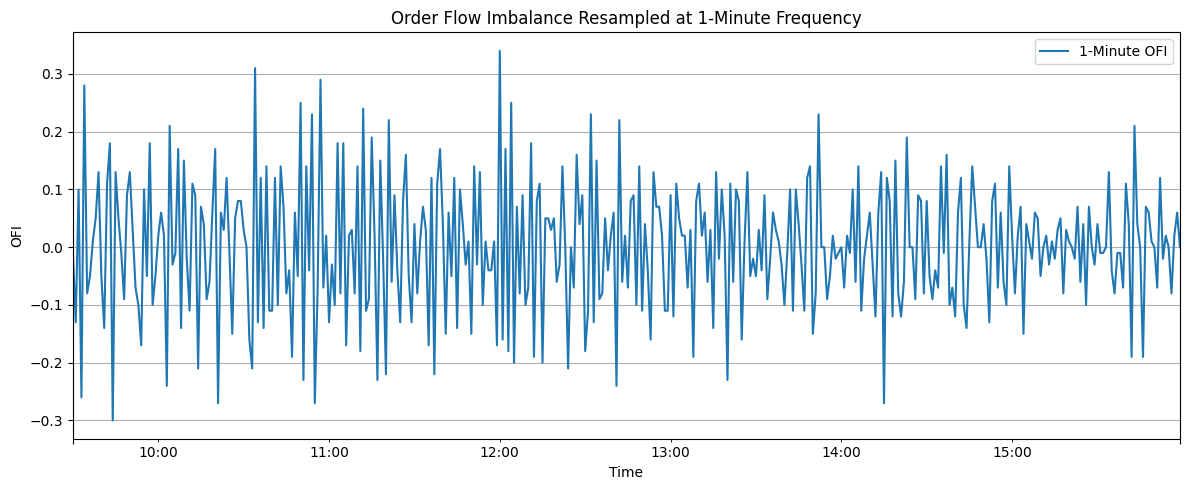

In [118]:
#df.set_index('DateTime', inplace = True, drop = False)

ofi_1min = df['OFI'].resample('1Min').sum()

ofi_1min_mean = df['OFI'].resample('1Min').mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
ofi_1min.plot(label='1-Minute OFI')
plt.title('Order Flow Imbalance Resampled at 1-Minute Frequency')
plt.xlabel('Time')
plt.ylabel('OFI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Here we are looking at the mean OFi sampling over 1 minute however what is useful is we can use this measure to calculate teh aggregate price impact, so we want to look at a time window T that contains a certain number of events and then we want to look at the OFi aggregated over T and we want to see what is the relationship with the price impact, the average price impact over the time window. 

What cont  et al do in there seminal paper si they define a linear relationship between the order flow and the price impact. The flow imbalance can change because of the events, for example consume liquidity at best and in that case mechanically we will ahve a price change. And what they do in there paper is they try to fit a linear relaitonship. This approximation when we consider price impact is linear in a number of models kyles and for traders behaviour. what we find in observations and what we showed plotting the aggregate reponse vs quantity is that it is true that the change in price vs normalised volume we have a linear relationship in the region where the volume is small but at large volumes it fails to capture this relationship. Lookign aat the aggregate pricei impact is nice vecause we don't have to have granular information about all events int he market we can just aggregate over a windo wso we know how much on average the market has moved and you are tying to capture what uis going to be the expected price shift.

In aggregate this is a quanity that can be seen as a proxy for demand and demand and supply shift and how this translates into price movements.

We now claculate the aggeregate price impact of a market order over a time window t.

recall the aggregate price impact is 

I(V| T) = <p_t+T - p_t | V_t>_t


differently the marginal impact of a meta order is I(Q,T|S) = < P_ti + t = pti | Q: S>

The peak impact or the final impact 

I(Q, tf-ti) can be approximated by Y * sigmad * sign(Q)  (Q/V_d) ^ 1/2 where y is a dimensionless quantity between 0.2 - 0.4

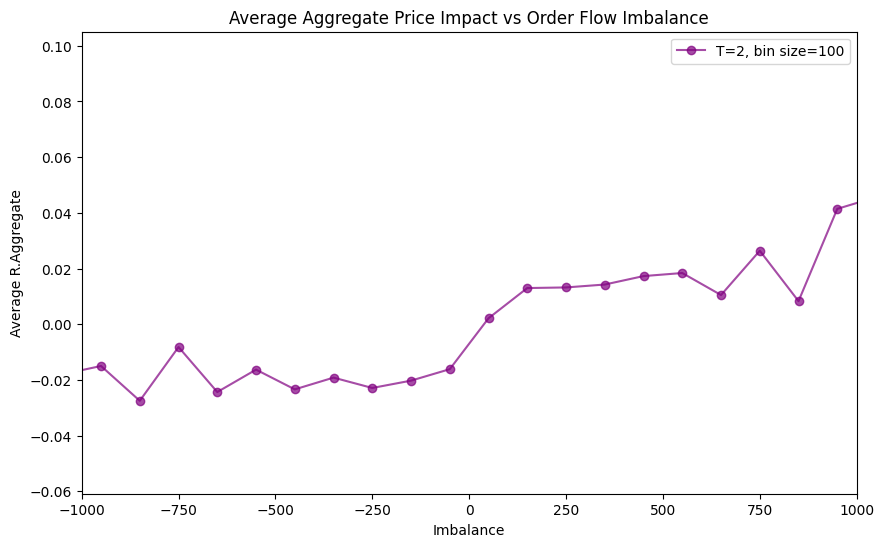

In [120]:
def calculate_aggregate_impact_and_imbalance(data, T, bin_size = 100):#

    imbalance_list = []
    impact_list = []

    market_orders = data[(data['Event_Type'] == 4) | (data['Event_Type'] == 5)]

    for i in range(0, len(market_orders) - T, T):
        window = market_orders.iloc[i:i + T]

        buy_volume = window[window['Direction'] == 1]['Size'].sum()
        sell_volume = window[window['Direction'] == -1]['Size'].sum()
        imbalance = sell_volume - buy_volume

        if len(window) == T:
            
            price_start = window.iloc[0]['Mid-Price']
            price_end = window.iloc[-1]['Mid-Price']

            impact = (price_end - price_start)

        else:
            print(f"window too small for lag")

        
        imbalance_list.append(imbalance)

        impact_list.append(impact)

    imbalance_list = np.array(imbalance_list)
    impact_list = np.array(impact_list)

    bins = np.arange(-2000, 2000 + bin_size, bin_size)
    binned_indices = np.digitize(imbalance_list, bins)

    average_impacts = []
    binned_imbalances = []

    for bin_num in range(1, len(bins)):
        bin_impacts = impact_list[binned_indices == bin_num]
        if len(bin_impacts) > 0:
                avg_impact = np.mean(bin_impacts)
                average_impacts.append(avg_impact)
                # Calculate the midpoint of each bin
                bin_midpoint = (bins[bin_num] + bins[bin_num - 1]) / 2
                binned_imbalances.append(bin_midpoint)

    return np.array(binned_imbalances), np.array(average_impacts)

T = 2  # Time window of T market orders
bin_size = 100  # Set bin size for imbalance

# Assuming df is the DataFrame containing the relevant market order data
# Call the function to calculate aggregate impact and imbalance, averaged by bins
binned_imbalances, average_impacts = calculate_aggregate_impact_and_imbalance(df, T, bin_size)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(binned_imbalances, average_impacts, '-o', color='purple', alpha=0.7, label=f'T={T}, bin size={bin_size}')
plt.xlabel('Imbalance')
plt.ylabel('Average R.Aggregate')
plt.title('Average Aggregate Price Impact vs Order Flow Imbalance')
plt.xlim([-1000, 1000])  # Limit x-axis to -1000 to 1000
plt.legend(loc='best')
plt.show()


The slope of this is kyles lambda which is an inverse measure of liquidity that is it is a measure of illiquidity. Since this value is small this means that the market is very liquid which is expected for TSLA, we see that imbalance has littel impact on price purely because of the liquidity in the market.st